In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

plt.style.use("ggplot")
sns.set_palette("viridis")

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


In [2]:
#carregamento de dados 
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()

Dataset carregado: 7043 linhas e 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Informações do dataset:")
df.info()

print("\nValores faltantes por coluna:")
print(df.isnull().sum())

df.describe(include="all").T

Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
print("Distribuição de Churn:")
print(df['Churn'].value_counts())
print("\nPorcentagem de churn:")
print(df['Churn'].value_counts(normalize=True) * 100)

Distribuição de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentagem de churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

print("Valores faltantes após conversão de TotalCharges:")
print(df_clean.isnull().sum())

Valores faltantes após conversão de TotalCharges:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [7]:
# Transformando Churn em número (0 e 1) pra facilitar
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})

print("Taxa de Churn:", df_clean['Churn'].mean().round(3))

Taxa de Churn: 0.265


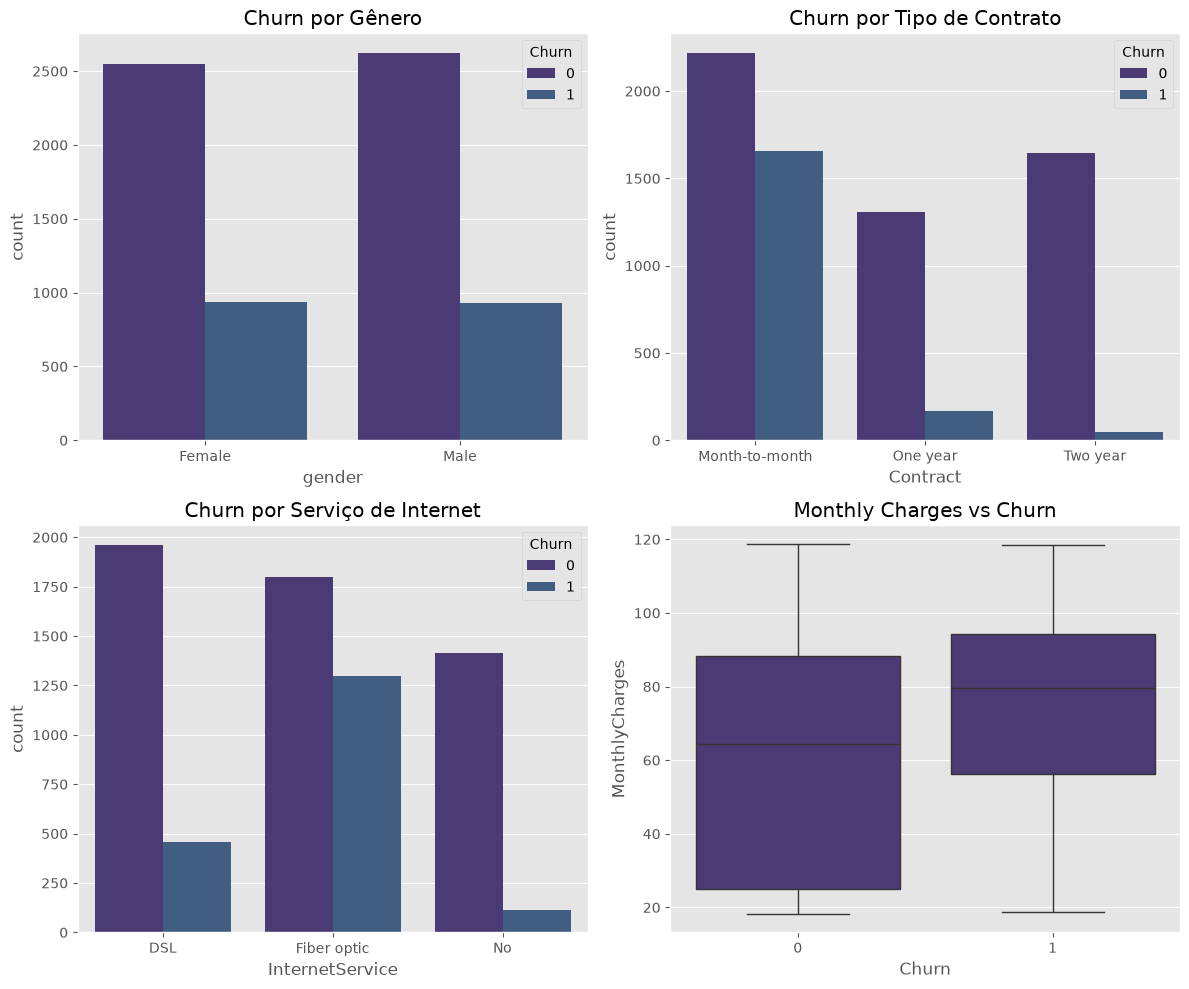

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=df_clean, x='gender', hue='Churn', ax=axes[0,0])
axes[0,0].set_title('Churn por Gênero')

sns.countplot(data=df_clean, x='Contract', hue='Churn', ax=axes[0,1])
axes[0,1].set_title('Churn por Tipo de Contrato')

sns.countplot(data=df_clean, x='InternetService', hue='Churn', ax=axes[1,0])
axes[1,0].set_title('Churn por Serviço de Internet')

sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', ax=axes[1,1])
axes[1,1].set_title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

In [9]:
# Analisando algumas variáveis importantes
print("Churn por Tipo de Contrato:")
print(df_clean.groupby('Contract')['Churn'].mean())

print("\nChurn por Serviço de Internet:")
print(df_clean.groupby('InternetService')['Churn'].mean())

print("\nChurn por Senior Citizen:")
print(df_clean.groupby('SeniorCitizen')['Churn'].mean())

Churn por Tipo de Contrato:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

Churn por Serviço de Internet:
InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64

Churn por Senior Citizen:
SeniorCitizen
0    0.236062
1    0.416813
Name: Churn, dtype: float64


In [10]:
# Criando novas colunas que podem ajudar o modelo

# Contando quantos serviços o cliente realmente possui
service_columns = [
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_clean["TotalServices"] = (
    df_clean[service_columns] == "Yes"
).sum(axis=1)

# Indica se o cliente possui algum serviço de internet
df_clean["HasInternet"] = (
    df_clean["InternetService"] != "No"
).astype(int)

# Indica se o cliente utiliza fibra ótica
df_clean["HasFiber"] = (
    df_clean["InternetService"] == "Fiber optic"
).astype(int)

print("Novas colunas criadas!")

df_clean[
    [
        "TotalServices",
        "HasInternet",
        "HasFiber"
    ]
].head()

Novas colunas criadas!


,TotalServices,HasInternet,HasFiber
0,1,1,0
1,3,1,0
2,3,1,0
3,3,1,0
4,1,1,1


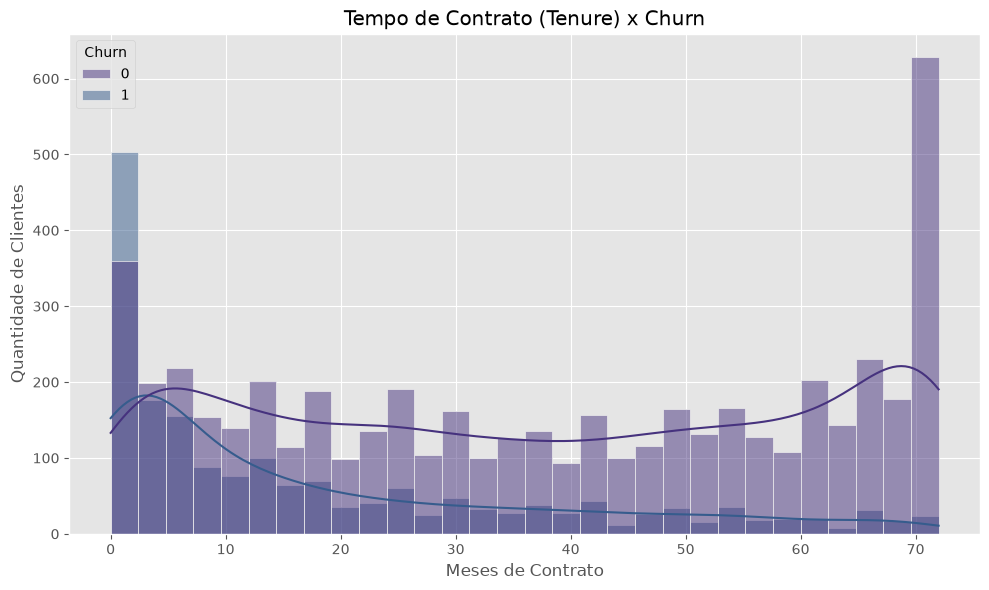

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="tenure",
    hue="Churn",
    kde=True,
    bins=30
)

plt.title("Tempo de Contrato (Tenure) x Churn")
plt.xlabel("Meses de Contrato")
plt.ylabel("Quantidade de Clientes")

plt.tight_layout()
plt.show()

In [12]:
# Removendo a coluna de identificação
df_model = df_clean.drop(columns=["customerID"])

# Separando as variáveis preditoras e a variável alvo
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Separando os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Shape das features:", X.shape)
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Shape das features: (7043, 22)
Treino: 5634 amostras
Teste: 1409 amostras


In [13]:
# Identificando colunas categóricas e numéricas
categorical_columns = X_train.select_dtypes(
    include=["str", "category"]
).columns.tolist()

numerical_columns = X_train.select_dtypes(
    include="number"
).columns.tolist()

print("Variáveis categóricas:")
print(categorical_columns)

print("\nVariáveis numéricas:")
print(numerical_columns)

Variáveis categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Variáveis numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'HasInternet', 'HasFiber']


In [14]:
# Pipeline para variáveis numéricas
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Pipeline para variáveis categóricas
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            )
        )
    ]
)

In [15]:
# Combinando os preprocessamentos
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_columns
        ),
        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ]
)

In [16]:
# Criando um pipeline completo para cada modelo

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, random_state=42))
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(
                n_estimators=200,
                random_state=42
            ))
        ]
    ),

    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            ))
        ]
    )
}

# Treinando e avaliando os modelos
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_pred_proba)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "auc": auc,
        "recall": recall,
        "f1": f1
    }

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"ROC-AUC : {auc:.4f}")
    print(f"Recall  : {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()

Logistic Regression
ROC-AUC : 0.8419
Recall  : 0.5642
F1-score: 0.6081

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[926 109]
 [163 211]]

Random Forest
ROC-AUC : 0.8223
Recall  : 0.4893
F1-score: 0.5495

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Confusion Matrix:
[[926 109]
 [191 183]]

XGBoost
ROC-AUC : 0.8190
Recall  : 0.5187
F1-score: 0.5496

Classification Rep

In [17]:
# Comparando os resultados dos modelos

results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by="auc",
    ascending=False
)

print("Comparação dos modelos:")
display(results_df.round(4))

Comparação dos modelos:


,auc,recall,f1
Logistic Regression,0.8419,0.5642,0.6081
Random Forest,0.8223,0.4893,0.5495
XGBoost,0.8190,0.5187,0.5496


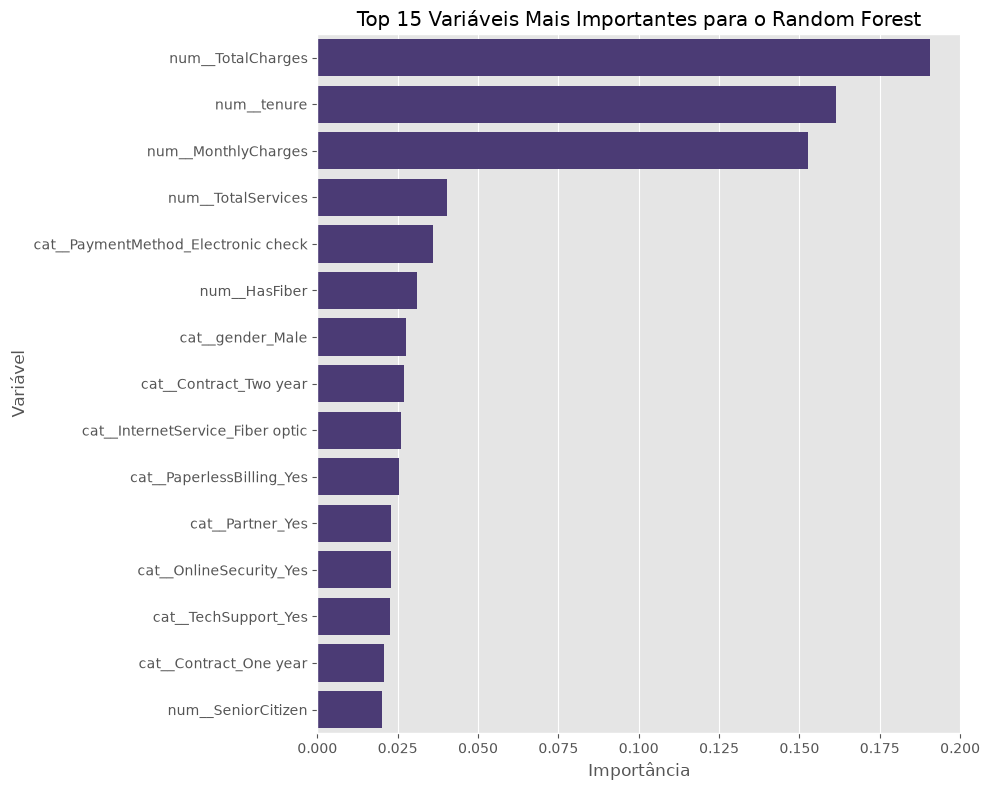

Top 15 variáveis mais importantes:
num__TotalCharges                      0.190674
num__tenure                            0.161259
num__MonthlyCharges                    0.152673
num__TotalServices                     0.040313
cat__PaymentMethod_Electronic check    0.035913
num__HasFiber                          0.031052
cat__gender_Male                       0.027660
cat__Contract_Two year                 0.026909
cat__InternetService_Fiber optic       0.026047
cat__PaperlessBilling_Yes              0.025483
cat__Partner_Yes                       0.023071
cat__OnlineSecurity_Yes                0.022970
cat__TechSupport_Yes                   0.022644
cat__Contract_One year                 0.020813
num__SeniorCitizen                     0.020210
dtype: float64


In [18]:
# Feature Importance - Random Forest

rf_pipeline = models["Random Forest"]

# Pegando o modelo Random Forest treinado
rf_model = rf_pipeline.named_steps["classifier"]

# Pegando o preprocessing treinado
rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

# Recuperando os nomes das features depois do encoding
feature_names = rf_preprocessor.get_feature_names_out()

# Importâncias calculadas pelo Random Forest
importances = rf_model.feature_importances_

# Criando ranking das 15 features mais importantes
feat_imp = pd.Series(
    importances,
    index=feature_names
).sort_values(ascending=False).head(15)

# Gráfico
plt.figure(figsize=(10, 8))

sns.barplot(
    x=feat_imp.values,
    y=feat_imp.index
)

plt.title("Top 15 Variáveis Mais Importantes para o Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

print("Top 15 variáveis mais importantes:")
print(feat_imp)

In [19]:
print("=" * 70)
print("CONCLUSÕES E RECOMENDAÇÕES DE NEGÓCIO")
print("=" * 70)

# Identificando automaticamente o melhor modelo pela ROC-AUC
best_model_name = results_df.index[0]
best_auc = results_df.iloc[0]["auc"]

print(
    f"\n• Melhor modelo: {best_model_name} "
    f"(ROC-AUC = {best_auc:.4f})"
)

print("\n• Padrões associados a maior churn:")
print("   - Clientes com contratos mensais")
print("   - Menor tempo de relacionamento com a empresa")
print("   - Mensalidades mais altas")
print("   - Clientes que utilizam serviço de fibra ótica")

print("\n• Possíveis ações de negócio:")
print("   - Incentivar a migração para contratos de maior duração")
print("   - Priorizar ações de retenção nos primeiros meses do relacionamento")
print("   - Avaliar clientes com mensalidades mais elevadas")
print("   - Investigar a experiência dos clientes que utilizam fibra ótica")
print("   - Criar estratégias de retenção para clientes classificados como alto risco")

CONCLUSÕES E RECOMENDAÇÕES DE NEGÓCIO

• Melhor modelo: Logistic Regression (ROC-AUC = 0.8419)

• Padrões associados a maior churn:
   - Clientes com contratos mensais
   - Menor tempo de relacionamento com a empresa
   - Mensalidades mais altas
   - Clientes que utilizam serviço de fibra ótica

• Possíveis ações de negócio:
   - Incentivar a migração para contratos de maior duração
   - Priorizar ações de retenção nos primeiros meses do relacionamento
   - Avaliar clientes com mensalidades mais elevadas
   - Investigar a experiência dos clientes que utilizam fibra ótica
   - Criar estratégias de retenção para clientes classificados como alto risco


In [20]:
print("=" * 60)
print("RESUMO FINAL DO PROJETO")
print("=" * 60)

print("Objetivo: Prever churn de clientes de telecomunicações")

print(
    f"Melhor modelo: {best_model_name} "
    f"(ROC-AUC = {best_auc:.4f})"
)

print("Quantidade de clientes analisados:", len(df))

print("\nEste projeto demonstra:")
print("- Análise exploratória de dados")
print("- Limpeza e preparação dos dados")
print("- Feature Engineering")
print("- Pipeline de preprocessing")
print("- Comparação de modelos de Machine Learning")
print("- Avaliação com ROC-AUC, Recall e F1-score")
print("- Análise de importância das variáveis")
print("- Interpretação dos resultados para o negócio")

RESUMO FINAL DO PROJETO
Objetivo: Prever churn de clientes de telecomunicações
Melhor modelo: Logistic Regression (ROC-AUC = 0.8419)
Quantidade de clientes analisados: 7043

Este projeto demonstra:
- Análise exploratória de dados
- Limpeza e preparação dos dados
- Feature Engineering
- Pipeline de preprocessing
- Comparação de modelos de Machine Learning
- Avaliação com ROC-AUC, Recall e F1-score
- Análise de importância das variáveis
- Interpretação dos resultados para o negócio


In [21]:
import os
print(os.getcwd())

C:\Users\Isabele\previsao-churn-clientes\previsao-churn-clientes\notebooks
